<div class="alert alert-block alert-info">
<H1> Notebook Instructions </H1><BR>
1. Press <mark>Shift</mark> + <mark>Enter</mark> to run the cells.<BR>
2. All the Jupyter notebook and data files can be downloaded from the LMS. Please prefix your query with <mark>Support</mark> if you are facing issues in locating the files. If you are watching offline, then reach out to your support manager at <mark>support@quantinsti.com.</mark><BR>
3. If you are new to Jupyter notebook, then read <a href= "https://blog.quantinsti.com/jupyter-notebook-tutorial-installation-components-magic-commands/">this guide</a>.
</div>

## Strategy Framework

This notebook demonstrates the process of backtesting a quantitative trading strategy. The goal is to evaluate the strategy's performance on historical data.

### Outline
1.  **Data Setup**: We will import the necessary Python libraries and fetch the historical stock data for our analysis.
2.  **Defining Alphas**: This section focuses on creating the core logic of our trading signals (alphas).
3.  **Generating Signals**: We'll combine the individual alpha signals to generate a final, unified trading signal.
4.  **Performance Analysis**: We will evaluate the historical performance of the strategy by calculating returns and generating key performance metrics.
5.  **Trade Details**: A detailed analysis of the individual trades generated by the strategy, including the calculation of Profit and Loss (PnL) after considering transaction costs.
6.  **Conclusion & Next Steps**: We will summarize the findings and discuss potential improvements for the strategy.

### 1. Data Setup

First, we import the required libraries and define the parameters for our backtest, such as the start and end dates and the financial instrument we want to analyze.

In [1]:
# Import the pandas library for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import the warnings library to manage warning messages
import warnings
warnings.simplefilter("ignore")

# Import the date class from the datetime module to define date ranges
from datetime import date

# Import plotting libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set the starting date for the backtesting period
start_date = date(2017, 1, 1)  # Start of the analysis period (January 1, 2017)

# Set the ending date for the backtesting period
end_date = date(2025, 6, 20)  

# Define the name of the financial instrument to be analyzed
instrument_name = 'LICHSGFIN.NS'  # Example: LIC Housing Finance Limited (NSE ticker)

In [2]:
from data import get_stock_data
data = get_stock_data(instrument_name, start_date, end_date)

[*********************100%***********************]  1 of 1 completed


Let's visualize the closing price of the stock for the first 100 days of our dataset to get a feel for the data.

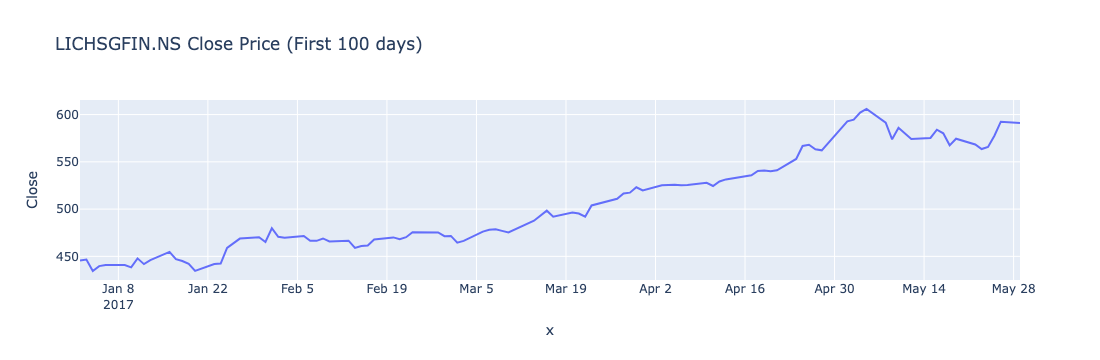

In [20]:
# Define the number of data points to visualize
t = 100  # Plot the first 100 data points from the dataset

# Plot the 'Close' prices using Plotly
fig = px.line(data.head(t), x=data.head(t).index, 
              y='Close', title=f'{instrument_name} Close Price (First {t} days)',
             height=500)
fig.show()

### 2. Defining Alphas

In this section, we define the 'alphas' or the predictive signals for our strategy.

#### Moving Average (MA) Crossover

A bullish signal (go long) is generated when a short-term moving average crosses above a long-term moving average.

In [21]:
# Import the required functions for the strategy
from alpha import ma_crossover, compute_adx

# Define the lookback periods for the exponential moving averages
short_lookback = 2  
long_lookback = 7

# Apply the MA cross-over strategy to the dataset
data = ma_crossover(data, short_lookback, long_lookback)

The following chart visualizes the short-term and long-term moving averages, along with markers indicating the crossover points, which represent our buy and sell signals.

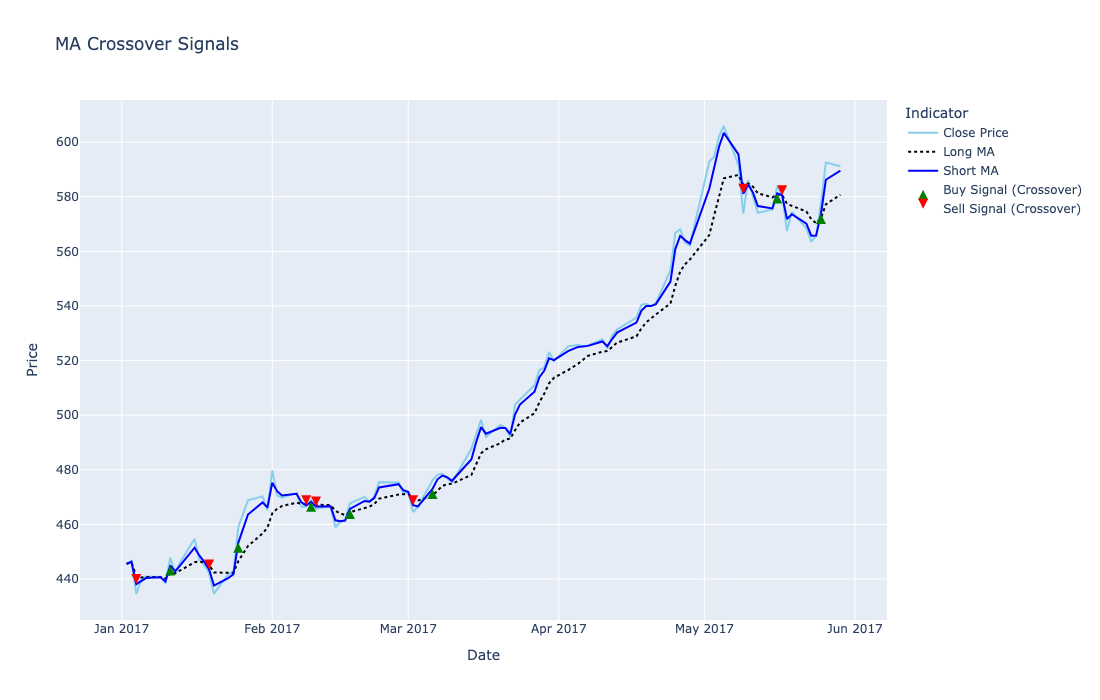

In [34]:
# Create temporary columns for crossover points for plotting
data['long_cross_over'] = np.where((data.ma_short >= data.ma_long) & (data.ma_short.shift(1) < data.ma_long.shift(1)), data.ma_short, np.nan)
data['square_off_cross_over'] = np.where((data.ma_short <= data.ma_long) & (data.ma_short.shift(1) > data.ma_long.shift(1)), data.ma_short, np.nan)

# Plot the MAs and crossover points using Plotly
fig = go.Figure()

t = 100 # number of days to plot
df_plot = data.head(t)

fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['Close'], mode='lines', name='Close Price', line=dict(color='skyblue')))
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['ma_long'], mode='lines', name='Long MA', line=dict(dash='dot', color='black')))
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['ma_short'], mode='lines', name='Short MA', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['long_cross_over'], mode='markers', name='Buy Signal (Crossover)', marker=dict(color='green', symbol='arrow-up', size=10)))
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['square_off_cross_over'], mode='markers', name='Sell Signal (Crossover)', marker=dict(color='red', symbol='arrow-down', size=10)))

fig.update_layout(title='MA Crossover Signals', xaxis_title='Date', yaxis_title='Price', legend_title='Indicator', height=700)
fig.show()

#### Average Directional Index (ADX)

The ADX is used to quantify the strength of a trend, regardless of its direction. An ADX value above a certain threshold (e.g., 20 or 25) suggests a strong trend, which is when trend-following strategies like MA Crossover are most effective. We will use the ADX as a filter: we will only take trades when the ADX indicates a strong trend.

In [28]:
# Calculate the ADX with a lookback period of 20
data = compute_adx(data, 20)

### 3. Generating the Final Signal
Now, we combine our two alphas. A final buy signal (`signal` = 1) is generated only when both the MA Crossover gives a buy signal and the ADX is above its threshold, indicating a strong trend. The position is exited when the MA Crossover gives a sell signal.

In [29]:
# The final signal is a product of the MA signal and the ADX trend signal.
# A trade is initiated only if ma_signal is 1 AND adx_signal is 1.
data['signal'] = data['ma_signal'] * data['adx_signal']

# Fill any missing values in the signal column with 0 (no position)
data['signal'] = data['signal'].fillna(0)

This chart visualizes the stock's closing price along with the final trading signal on a secondary y-axis. The green shaded areas indicate the periods when our strategy holds a long position.

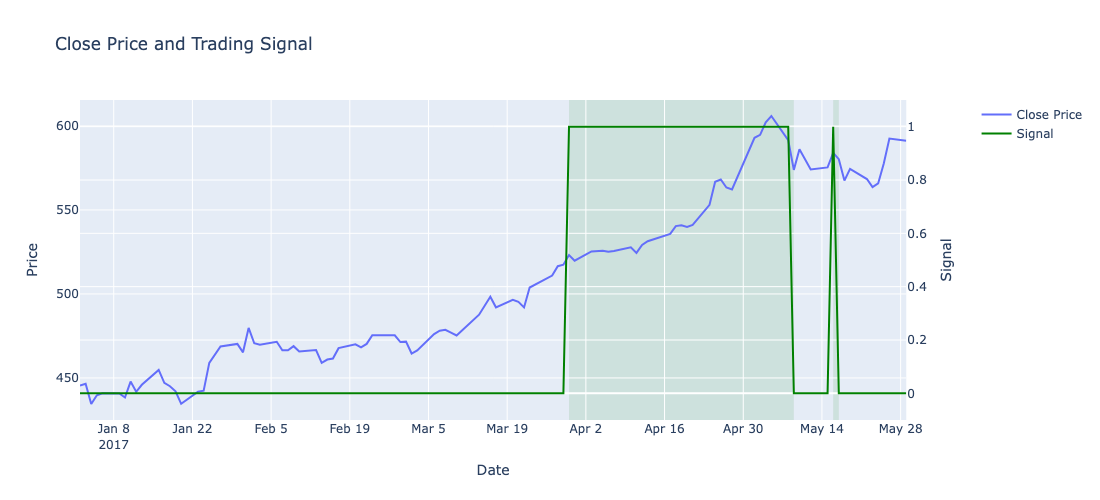

In [35]:
# Plot the Close price and the final signal
x = 100 # number of days to plot
df_plot = data.head(x)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['Close'], name='Close Price'), secondary_y=False)
fig.add_trace(go.Scatter(x=df_plot.index, y=df_plot['signal'], name='Signal', line=dict(color='green')), secondary_y=True)

# Add shaded regions for long positions
in_position = False
start_date = None
for i in range(len(df_plot)):
    if df_plot['signal'].iloc[i] == 1 and not in_position:
        in_position = True
        start_date = df_plot.index[i]
    elif df_plot['signal'].iloc[i] == 0 and in_position:
        in_position = False
        end_date = df_plot.index[i]
        fig.add_vrect(x0=start_date, x1=end_date, fillcolor="green", opacity=0.1, layer="below", line_width=0)

fig.update_layout(title_text='Close Price and Trading Signal', height=500)
fig.update_xaxes(title_text="Date")
fig.update_yaxes(title_text="Price", secondary_y=False)
fig.update_yaxes(title_text="Signal", secondary_y=True, range=[-0.1, 1.1])
fig.show()

### 4. Performance Analysis
With the trading signals generated, we can now analyze the performance of our strategy.

#### Compute Daily and Cumulative Returns
We calculate the daily returns of the strategy. The strategy return is the stock's daily return multiplied by the signal from the previous day (since we can only trade based on signals from the close of the previous day).

In [36]:
# Import the performance analytics function
# The 'performance_analytics.py' file should be in the same directory.
from performance_analytics import compute_ret

# Compute the daily returns of the strategy
data = compute_ret(data)

#### Daily Strategy Returns Histogram
The histogram below shows the distribution of the daily returns of our strategy. This helps us understand the frequency and magnitude of daily profits and losses.

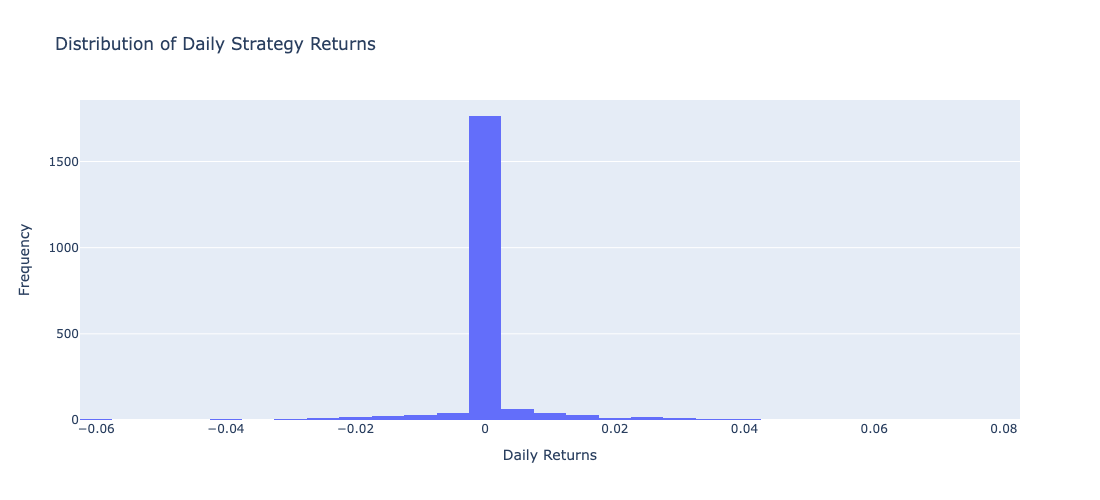

In [37]:
# Plot the histogram of daily strategy returns
fig = px.histogram(data, x="strategy_ret", nbins=30, title='Distribution of Daily Strategy Returns')
fig.update_layout(xaxis_title='Daily Returns', yaxis_title='Frequency', height=500)
fig.show()

#### Cumulative Strategy Returns
The cumulative returns chart is a key visual for assessing performance. It shows the growth of a hypothetical investment over the backtesting period.

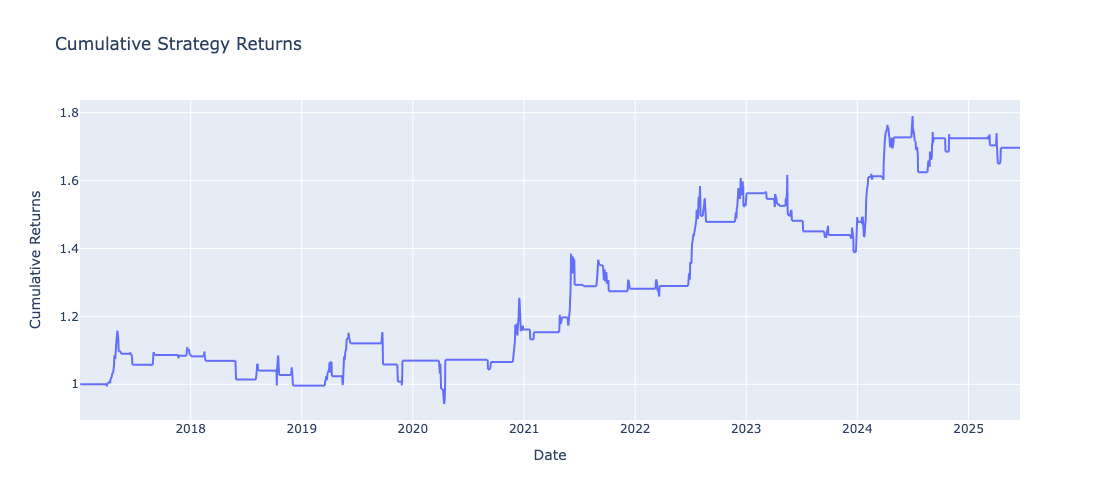

In [38]:
# Calculate and plot the cumulative returns
data['cumulative_strategy_ret'] = (data.strategy_ret + 1.0).cumprod()
fig = px.line(data, y='cumulative_strategy_ret', title='Cumulative Strategy Returns')
fig.update_layout(yaxis_title='Cumulative Returns', xaxis_title='Date', showlegend=False, height=500)
fig.show()

#### Performance Metrics Tear Sheet

We use the `pyfolio` library to generate a comprehensive performance report, known as a tear sheet. This provides key metrics like Annual Return, Sharpe Ratio, Max Drawdown, and more.

Start date,2017-01-02
End date,2025-06-19
Total months,99
,Backtest
Annual return,6.579%
Cumulative returns,69.675%
Annual volatility,12.85%
Sharpe ratio,0.56
Calmar ratio,0.35
Stability,0.86
Max drawdown,-18.681%


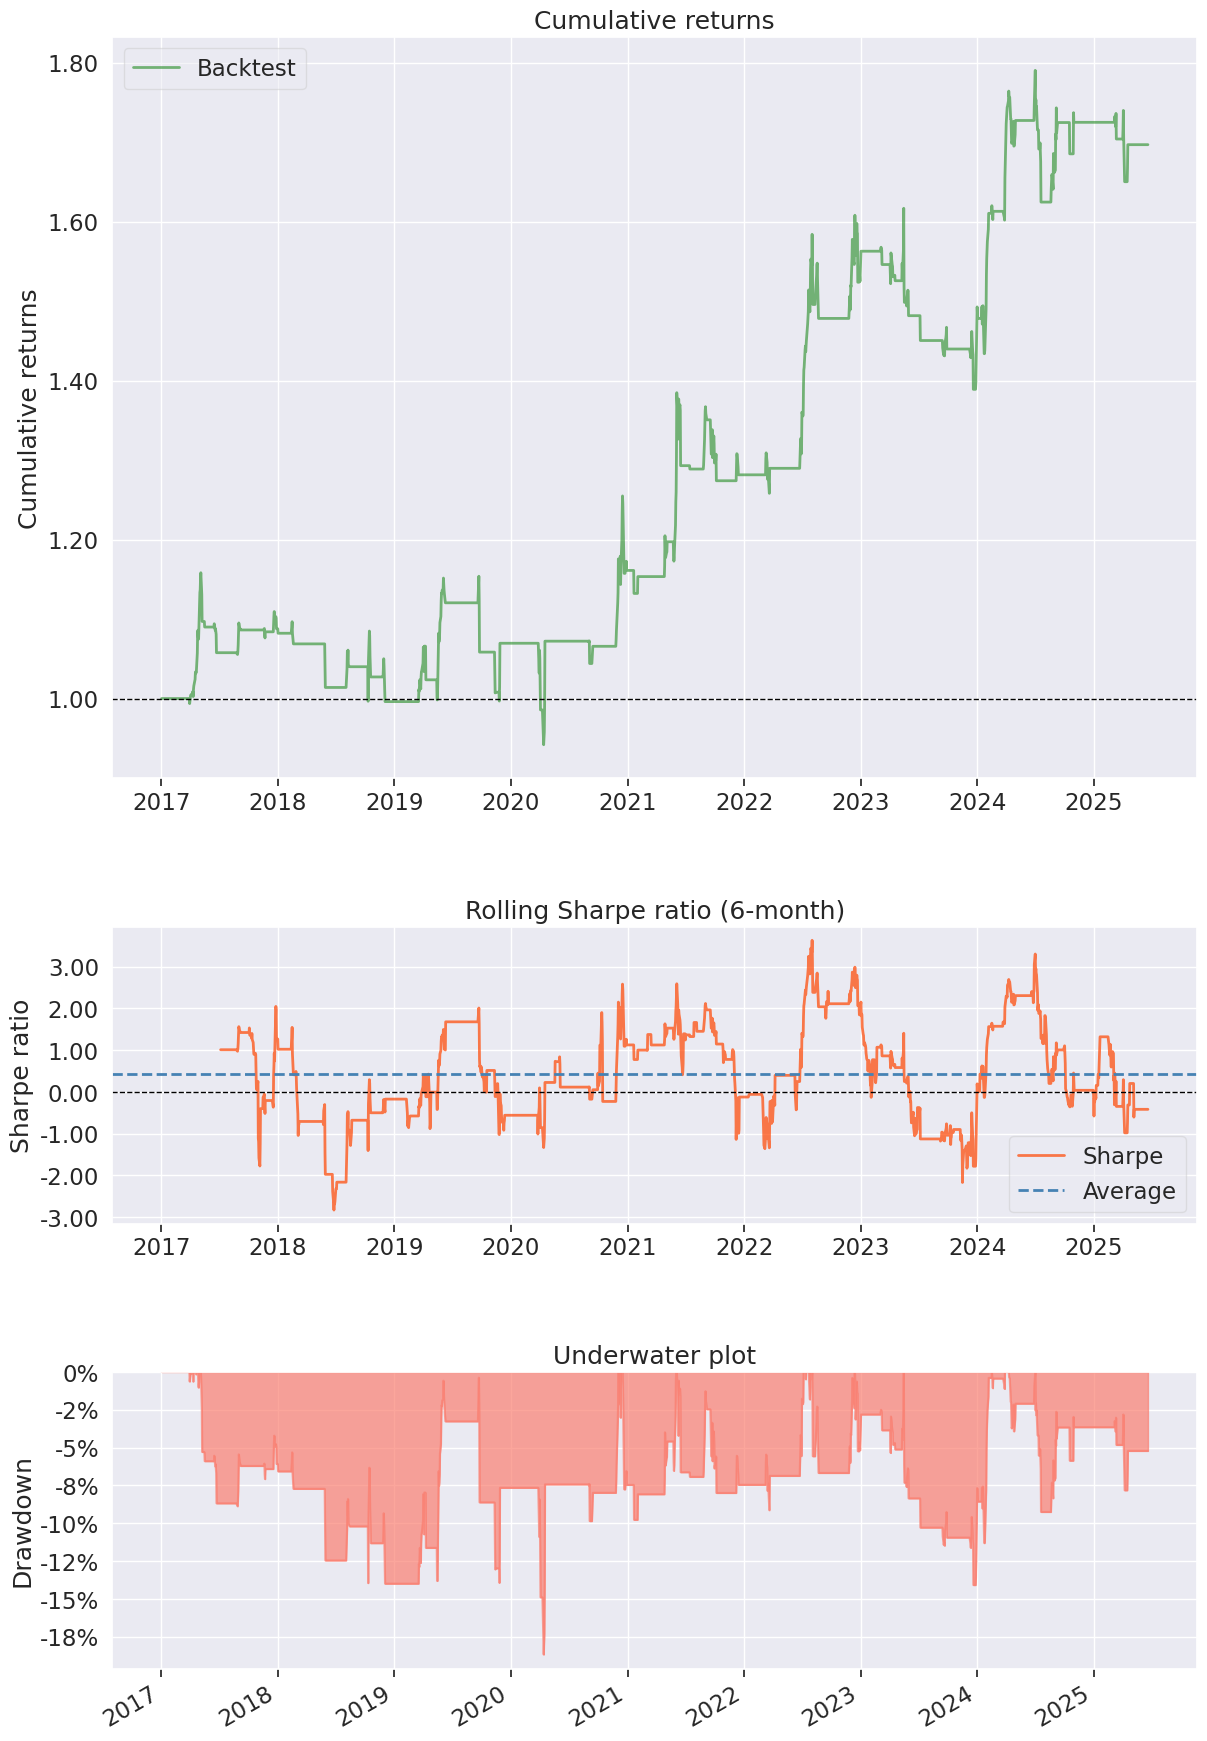

In [39]:
# Uncomment the line below to install pyfolio if you haven't already
# !pip install pyfolio-reloaded
import pyfolio as pf
pf.create_simple_tear_sheet(data.strategy_ret)

### 5. Trade Details
To get a more granular view, we'll now extract and analyze the individual trades made by the strategy.

#### Generating the Trade Log
This function iterates through our signal data and compiles a log of all trades, recording the entry and exit times and prices for each position.

In [14]:
def get_trades(data, close_column, signal_column):
    """Function to generate trade details
    
    Args:
        data (pd.DataFrame): DataFrame with price and signal data.
        close_column (str): The name of the column with close prices.
        signal_column (str): The name of the column with the trading signal.
        
    Returns:
        pd.DataFrame: A DataFrame containing the details of each trade.
    """
    trades = pd.DataFrame()
    current_position = 0
    entry_time = ''

    # Using .loc for safer indexing
    for i in data.index:
        new_position = data.loc[i, signal_column]
        if new_position != current_position:    

            if entry_time != '':                   
                entry_price = data.loc[entry_time, close_column]
                exit_time = i
                exit_price = data.loc[exit_time, close_column]
                trade_details = pd.DataFrame([(current_position, entry_time, entry_price, exit_time, exit_price)])
                trades = pd.concat([trades, trade_details], ignore_index=True)
                entry_time = ''            

            if new_position != 0:
                entry_time = i
            current_position = new_position


    trades.columns = ['Position','Entry Time','Entry Price','Exit Time','Exit Price']
    trades['PnL'] = (trades['Exit Price'] - trades['Entry Price']) * trades['Position']
    return trades

In [15]:
trades = get_trades(data, 'Close', 'signal')
print('Trade Details (First 5 Trades)')
print('--------------------------------')
print('Total PnL (before costs): %.2f'% (trades.PnL.sum()))
trades.head()

Trade Details (First 5 Trades)
--------------------------------
Total PnL (before costs): 248.11


,Position,Entry Time,Entry Price,Exit Time,Exit Price,PnL
0,1.0,2017-03-30,523.135254,2017-05-09,573.860107,50.724854
1,1.0,2017-05-16,583.988342,2017-05-17,580.248047,-3.740295
2,1.0,2017-06-15,652.742432,2017-06-23,633.410522,-19.331909
3,1.0,2017-08-24,558.090088,2017-09-06,573.187378,15.097290
4,1.0,2017-11-17,512.798218,2017-11-23,511.695679,-1.102539


#### Accounting for Transaction Costs
No trading strategy analysis is complete without considering transaction costs. Here, we define a total cost (brokerage + taxes) and apply it to each trade to calculate the net PnL.

In [16]:
# Define brokerage and tax percentages
brokerage = 0.03/100
tax = 0.02/100
total_cost = brokerage + tax
print(f"Total transaction cost per trade: {total_cost*100:.3f}%")

Total transaction cost per trade: 0.050%


In [17]:
# Assume trading with a quantity of 1 for simplicity
quantity = 1

# Subtract transaction costs from the PnL of each trade
trades['PnL'] -= total_cost * (trades['Entry Price'] + trades['Exit Price']) * quantity

print('Trade Details (First 5 Trades after costs)')
print('------------------------------------------')
print('Total PnL (after costs): %.2f'% (trades.PnL.sum()))
trades.head()

Trade Details (First 5 Trades after costs)
------------------------------------------
Total PnL (after costs): 218.91


,Position,Entry Time,Entry Price,Exit Time,Exit Price,PnL
0,1.0,2017-03-30,523.135254,2017-05-09,573.860107,50.176356
1,1.0,2017-05-16,583.988342,2017-05-17,580.248047,-4.322414
2,1.0,2017-06-15,652.742432,2017-06-23,633.410522,-19.974986
3,1.0,2017-08-24,558.090088,2017-09-06,573.187378,14.531651
4,1.0,2017-11-17,512.798218,2017-11-23,511.695679,-1.614786


### 6. Improvements

1.  **How to reduce the drawdowns?**

2.  **How to improve the strategy performance?**

3.  **How to increase the Sharpe ratio?**